# Processes Derived from Brownian Motion

# Necessary Edits / Update <br>

All Sections:
* Clean up random notes in code or comments
* Update to use functions where possible.

Goal & Motivation Sections:
* Complete these. Currently unfinished

Brownian Bridge Section:
* Do a better job explaining theory or graphs. Especially why graphs on multiple motions "smush" when imposing the endpoint condition? <br>

Linear Drift Section: 
* Define sigma
* I took away the brownian bridge from these examples so as not to confuse on what a drift does. May need to comment somewhere else that these processes can be combined with one another

Geometric Brownian Motion:
* Veirfy that GBM is lognormal through simulation
* Verify claims on expected value and variance
* further documentation on the importance of this model for black scholes pricing and finance applications

White Noise section:
* What is the purpose of this section?
* Where am I grabbing the formulas from? Need greater proof. 

**Goal**

In this notebook, we explore processes derived from Brownian motion, including:
* Brownian Bridge
* Linear Drift
* Geometric Brownian Motion

**Motivation**

Recall from previous notebooks a simulation of 50 Brownian paths.

Text(0, 0.5, 'Path')

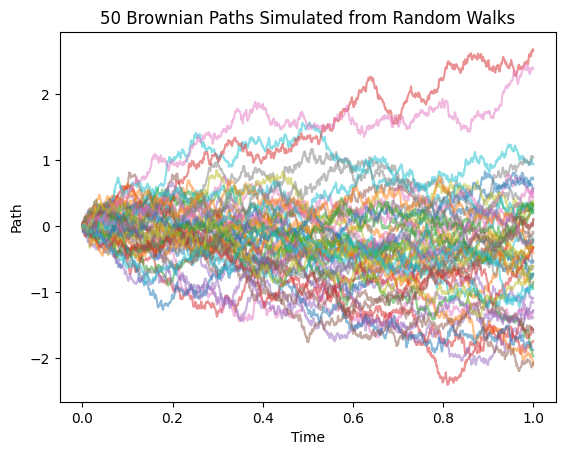

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate a random walk
def simulate_rw(n_sims, n_terms, T):
    dt = T / n_terms
    Z = np.random.normal(0,1,(n_sims,n_terms))
    W = (np.cumsum(np.sqrt(dt)*Z, axis =1))
    W = np.hstack([np.zeros((n_sims,1)),W])
    t = np.linspace(0, T, n_terms+1)
    return t, W
    
# Simulate many Brownian paths from Random Walks
t, W = simulate_rw(50,1000,1.0)
for i in range(len(W)):
   plt.plot(t,W[i,:],alpha=0.5)
plt.title("50 Brownian Paths Simulated from Random Walks")
plt.xlabel("Time")
plt.ylabel("Path")

What are some shortcomings here (depending on contexts)
* All paths start at the initial condition 0, but have varying endpoints. One may seek to impose an endpoint constraint (so that paths are random but end at the same place)
* These paths are random around a mean path of 0. We may hope to simulate randomness relative to some deterministic function.
* Notice that some marginals in our path are negative. For many contexts (such as stock price), negative values are quite undesirable or impossible. Thus, we may want to apply a transformation to Brownian motion that results in strictly non-negative values.
What additional properties 

# Brownian Bridge

A Brownian bridge is a transformation to traditional Brownian motion which applies an endpoint constraint.

Let $W_{t}$ be a Brownian motion on [0,1]. <br>
A Brownian bridge on [0,1] is defined as $B_{t} = W_{t} - tW_{1}$. <br>
This "ties down" the Brownian path with conditions $B_{0}=0$ and $B_{1}=0$, where the endpoint constraint is smoothly enforced.

**Properties**
* $E[B_{t}] = 0$
* $\operatorname{Cov}(B_{s},B_{t}) = min(s,t) - st$
    * Covariance is the shared Brownian randomness (min(s,t)) and a correction for "tying down" at t=1.
      
Since a Brownian Bridge is normal, mean and variance are the two functions necessary to describe the distribution.

**Intuitive Definition- Brownian Bridge is a Gaussian Process**
* Brownian motion is a Gaussian process because all its finite-dimensional distributions (fidis) are multivariate normal.
* A Brownian bridge is a linear transformation of Brownian motion, so its fidis are also multivariate normal.
* This makes a Brownian bridge a Gaussian process.
* The transformation in a bridge subtracts a linear term to smoothly enforce the contition $B_{1}=0$ as to preserve continuity.




In [3]:
# A fidi is the joint distribution of a stochastic process evaluated at a finite collection of time points. 
# Fidis can be of any finite size. The collection of all such joint distributions determines the distribution of the entire process. 
# Since all Brownian motion fidis are multivariate normal, Brownian motion is a Gaussian process.

Let's explore the construction of a Brownian bridge.

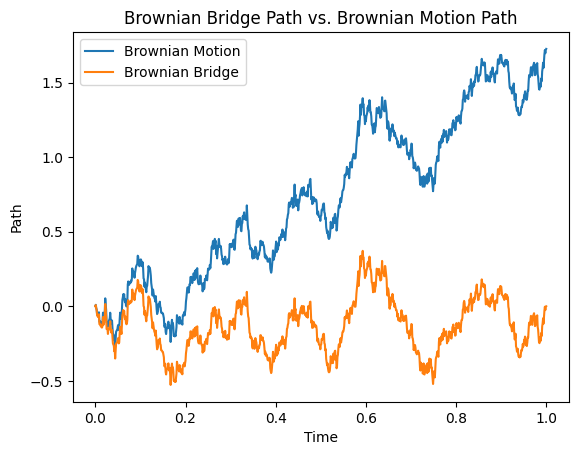

In [102]:
# time
T=1.0
#increments
n=1000
dt=T/n

# simulate increments to form one Brownian Path
Z=np.random.normal(0,1,n)
dW = np.sqrt(dt) * Z
W=np.cumsum(dW)
# Initial condition
W = np.insert(W,0,0) 
t=np.linspace (0, T, n+1)


# Create Brownian Bridge
W1 = W[-1]
B = W - t*W1

plt.plot(t, W, label = "Brownian Motion")
plt.plot(t,B, label = "Brownian Bridge")
plt.title("Brownian Bridge Path vs. Brownian Motion Path")
plt.xlabel("Time")
plt.ylabel("Path")
plt.legend()
plt.show()

Here, we compare a traditional Brownian motion to a Brownian bridge. <br>
If you compare the paths, each increment from the traditional Brownian motion looks visually the same as each increment from the bridge. <br>
However, over time, the bridge is brought closer to our end constraint that we hope to impose (here we chose 0). <br>
This is what is referenced by smooth enforcement of an endpoint condition.

Let's exapand this visualization to multiple Brownian bridges.

Text(0, 0.5, 'Path')

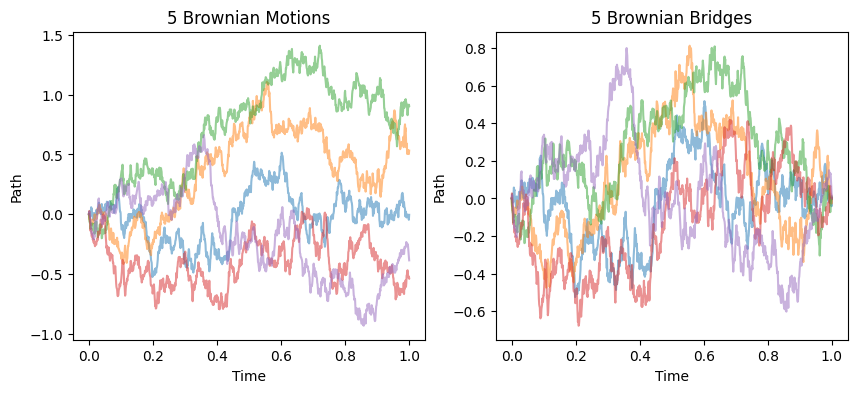

In [104]:
# Function to simulate a random walk
def simulate_bridge(n_sims, n_terms, T):
    dt = T / n_terms
    Z = np.random.normal(0,1,(n_sims,n_terms))
    W = (np.cumsum(np.sqrt(dt)*Z, axis =1))
    W = np.hstack([np.zeros((n_sims,1)),W])
    W1 = W[:,-1]
    t = np.linspace(0, T, n_terms+1)
    B = W - (t/T)*W1[:,np.newaxis] # Self note: np.newaxis required to make W1 an n_sims x 1 vector. Then (t/T)*W1 becomes an n_sims x n_terms+1 matrix.
    return t, B, W
    
# Simulate many Brownian paths from Random Walks
t, B, W = simulate_bridge(5,1000,1.0)
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
for i in range(len(B)):
    ax2.plot(t,B[i,:],alpha=0.5)
    ax1.plot(t,W[i,:],alpha=0.5)
ax1.set_title("5 Brownian Motions")
ax2.set_title("5 Brownian Bridges")
ax1.set_xlabel("Time")
ax1.set_ylabel("Path")
ax2.set_xlabel("Time")
ax2.set_ylabel("Path")

In the graphs above, we see how 5 paths Brownian motions (left) are transformed into Brownian bridges (right) by imposing an endpoint constraint of $W(1)=0$ smoothly for all paths. <br>

# Linear Drift

Up to now, we've looked at Brownian motion as randomness fluctuating around a mean of 0. <br>
What happens when we add in a deterministic trend?

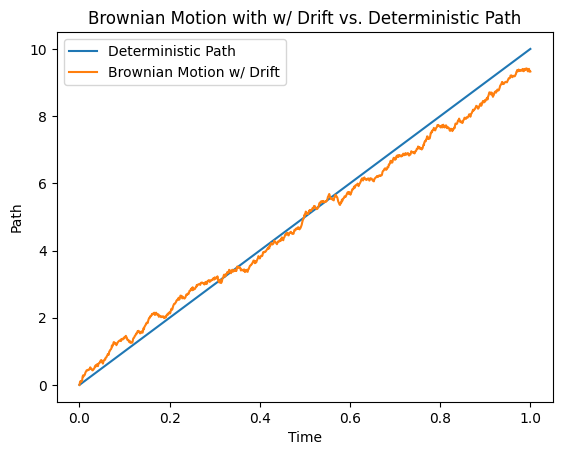

In [113]:
# simulate increments to form one Brownian Path
Z=np.random.normal(0,1,n)
dW = np.sqrt(dt) * Z
W=np.cumsum(dW)
W = np.insert(W,0,0) # Initial condition
t=np.linspace (0, T, n+1)


x = 10*t # Deterministic vector (Vector of values of the function f(t)= 10t at nodes in our mesh)

Y = x + W

# plot
plt.plot(t, x, label = "Deterministic Path")
plt.plot(t,Y, label = "Brownian Motion w/ Drift")
plt.title("Brownian Motion with w/ Drift vs. Deterministic Path")
plt.xlabel("Time")
plt.ylabel("Path")
plt.legend()
plt.show()

***The below comment needs better framing of what a linear drift actually is. What is Yt? base definition there. What is sigma?***

Above, we explored what is called a Brownian motion with drift. <br>
Our Brownian motion with drift is defined as $Y_{t} = 10t + B_{t}$, with$ B_{t}$ being our Brownian motion (Brownian bridge). <br>
Visually, we see that Brownian motion with drift is variation around a deterministic vector.
We can think of this as noise around a trend. Brownian motion gives us random noise, while the deterministic function gives us a linear trend. <br>
<br>
We can quickly show that $Y_{t}$ is still Brownian motion and still a Gaussian process. <br>
<br>
**With theory:** <br>
*Definition* <br>
    $Y_{t} = (\mu  t) + (\sigma  B_{t})$<br>
    *General Idea* <br>
    $B_{t}$ is a Brownian motion, and thus a Gaussian process. $Y_{t}$ is a linear transformation of a Gaussian process, which preserves Gaussian identity. <br>
    *Light proof* <br>
    Take a finite set $t_{1} ... t_{k}.$<br> 
    We have that the random vector $\begin{bmatrix}
    Y_{t_{1}} \ Y_{t_{2}} \ \ \dots \ Y_{t_{k}}
    \end{bmatrix}
    = \mu \begin{bmatrix}
    t_{1} \ t_{2}\ \dots{}\ t_{k}
    \end{bmatrix}
    + \sigma \begin{bmatrix}
    B_{t_{1}}\ B_{t_{2}}\ \dots{} \ B_{t_{k}}
    \end{bmatrix}$ <br>
    By definition, $\begin{bmatrix}
    B_{t_{1}}\ B_{t_{2}}\ \dots{} \ B_{t_{k}}
    \end{bmatrix}$ is multivariate normal. <br>
    Since sigma a constant, $\sigma \begin{bmatrix}
    B_{t_{1}}\ B_{t_{2}}\ \dots{} \ B_{t_{k}}
    \end{bmatrix}$ is still multivariate normal. <br>
    $\mu \begin{bmatrix}
    t_{1} \ t_{2}\ \dots{}\ t_{k}
    \end{bmatrix}$ is a deterministic vector. Adding this doesn't change normality, just shifts the mean. <br>
    Thus, $\begin{bmatrix}
    Y_{t_{1}} \ Y_{t_{2}} \ \ \dots \ Y_{t_{k}}
    \end{bmatrix}$ is a multivariate normal random vector. <br>
    It follows that the distribution (fidi) of  $\begin{bmatrix}
    Y_{t_{1}} \ Y_{t_{2}} \ \ \dots \ Y_{t_{k}}
    \end{bmatrix}$ is Gaussian. <br>
    Since we used an general finite set $\begin{bmatrix}
    t_{1} \ t_{2}\ \dots{}\ t_{k}
    \end{bmatrix}$, it holds that all fidis are Gaussian. <br>
    Thus, $Y_{t}$ is a Gaussian process.

**With Simulation**

Mean (theoretical ~ $\mu$): 5.002581343057584
Variance (theoretical ~ $\sigma^2$): 1.019032763678048


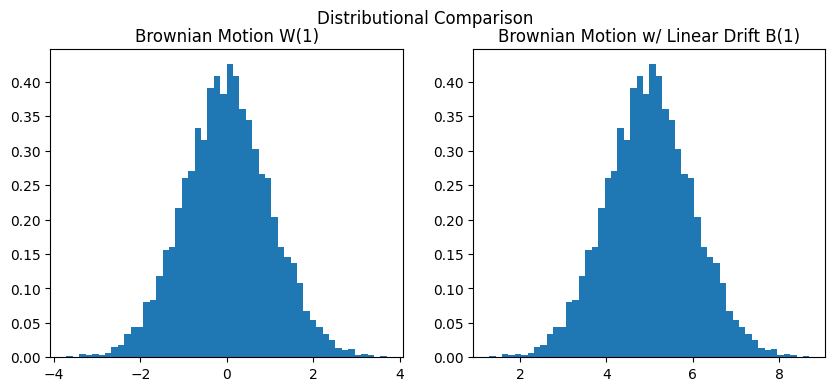

In [108]:
final_values_W = []
final_values_X = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 

mu = 5      # drift
sigma = 1   # volatility - What do we want for sigma? Is this a parameter? Or should it be sqrt(dt)?

for _ in range(10000):
    Z=np.random.normal(0,1,n)
    W=np.sum(np.sqrt(dt)*Z)
    final_values_W.append(W)
    # Drift introduced
    X = mu*T + sigma * W
    final_values_X.append(X)


# Mean should be close to 0
print("Mean (theoretical ~ $\\mu$):", np.mean(final_values_X))
# Variance should be close to 1
print("Variance (theoretical ~ $\\sigma^2$):", np.var(final_values_X))

# Distributions should be Gaussian (Normal). Check Histogram
ax1.hist(final_values_W, bins=50, density=True)
ax2.hist(final_values_X, bins=50, density=True)
fig.suptitle("Distributional Comparison")
ax1.set_title('Brownian Motion W(1)')
ax2.set_title('Brownian Motion w/ Linear Drift B(1)')
plt.show()


Note that our marginal distributions at time t = 1 are similar, and both are Gauss/Normal. <br>
As a result of linear drift, our mean has shifted from 0 to 5, and our drifted motion reflects any change in sigma as well (if present).


Now let's visualize multiple Brownian motions with drift.

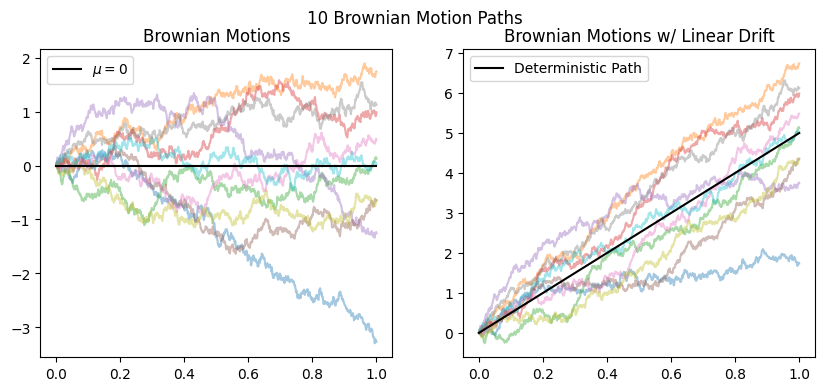

In [118]:
# Simulate many Brownian paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 
for _ in range(10):
    Z = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    B = W
    ax1.plot(t,B,alpha=0.4)
    # Deterministic vector
    x = 5*t
    Y = x + B
    ax2.plot(t,Y,alpha=0.4)

zeroline= np.zeros(n+1)  
ax1.plot(t,zeroline,alpha=1,color='black', label = "$\\mu = 0$")
ax2.plot(t,x,alpha=1,color='black', label = "Deterministic Path")
fig.suptitle("10 Brownian Motion Paths")
ax1.set_title('Brownian Motions')
ax2.set_title('Brownian Motions w/ Linear Drift')
ax1.legend()
ax2.legend()
plt.show()


We can see our Brownian motions on the left and those same motions with drift on the right. <br>
The left plot represents noise around a mean of zero, whereas the right plot shows our noise around a moving mean (our deterministic vector). <br>
Note that the noise is the same in both cases (we didn't scale here). Peaks and valleys of different Brownian motions are consistent across plots.

Intuitively, the properties of Brownian motion with drift apply to non-linear drifts as well (i.e. non-linear deterministic vectors).

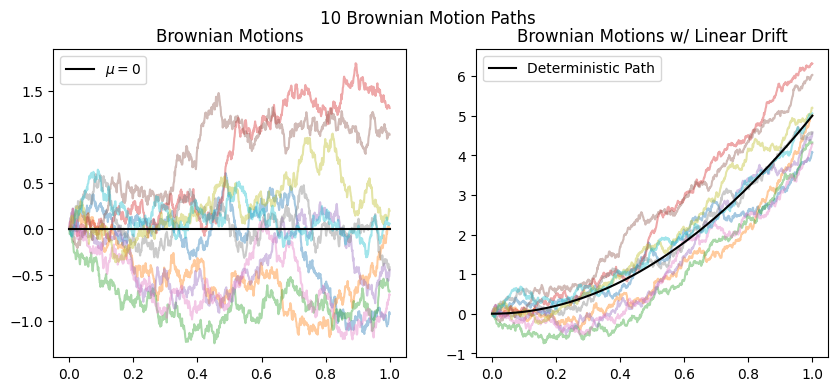

In [119]:
# Simulate many Brownian paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 
for _ in range(10):
    Z = np.random.normal(0,1,n)
    W = np.insert(np.cumsum(np.sqrt(dt)*Z),0,0)
    ax1.plot(t,W,alpha=0.4)
    # Deterministic vector
    x = 5* t**2
    Y = x + W
    ax2.plot(t,Y,alpha=0.4)

zeroline= np.zeros(n+1)  
ax1.plot(t,zeroline,alpha=1,color='black', label = "$\\mu = 0$")
ax2.plot(t,x,alpha=1,color='black', label = "Deterministic Path")
fig.suptitle("10 Brownian Motion Paths")
ax1.set_title('Brownian Motions')
ax2.set_title('Brownian Motions w/ Linear Drift')
ax1.legend()
ax2.legend()
plt.show()


Here we are transforming our Brownian motions with a quadratic drift. Since all we change is the function generating our deterministic vector, only our mean changes.

# Geometric Brownian Motion

As seen in prior explorations, traditional Brownian motion can take on negative values. For contexts such as stock pricing, this is quite an undesirable trait. So we aim to transform Brownian motion in a way that takes on only non-negative values. One famous transformation successful at this goal is called Geometric Brownian Motion, which is the exponential transformation of a Brownian motion with drift.

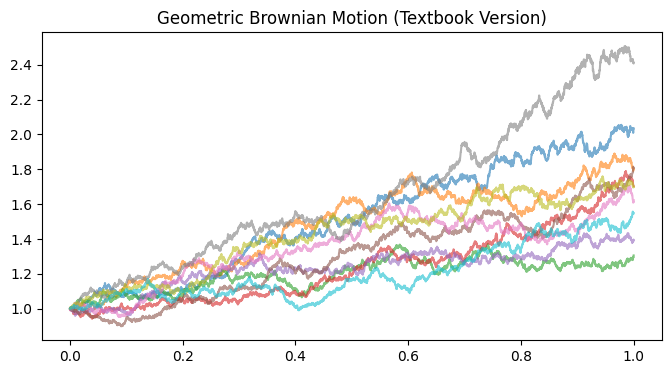

In [140]:
T = 1
n = 5000
dt = T/n
t = np.linspace(0, T, n+1)
mu = 0.5
sigma = 0.2
S0 = 1.0

fig, ax = plt.subplots(figsize=(8,4))

for _ in range(10):
    Z = np.random.normal(0,1,n)
    B = np.insert(np.cumsum(np.sqrt(dt)*Z), 0, 0)
    X = S0 * np.exp(mu*t + sigma*B)
    ax.plot(t, X, alpha=0.6)

ax.set_title("Geometric Brownian Motion (Textbook Version)")
plt.show()

Above, we see simulated paths from Geometric Brownian motion. 

**Properties of GBM:**
* Defined by $X_{t} = e^{\mu t + \sigma B_{t}}$
* $X_{t} > 0 \forall t$ <br>
    * This positivity constraint solves the issue of negativity in Brownian motion from a pricing context.
* $\ln X_{t} = \mu  t + \sigma  B_{t}$
    * It follows that X_{t} is log-normal. 
* $E[X_t] = e^{\mu t+0.5 \sigma^2 t}$
* $\operatorname{Var}(X_{T}) = (e^{2 \mu t+ \sigma^2 t})((e^{\sigma^2 t})-1)$
    * These expected value and variance functions come from the log-normal distribution (**Verify this**) <br>
<br>
This is the stochastic process which serves as the conceptual basis of Black - Scholes. Will build upon this moving forward.

# White noise vs. Colored noise

What follows is a brief exploration into white noise vs. colored noise. <br>
<br>
White noise is theoretical: independent Gaussian randomness at every infinitesimal instant. It is what underlies Brownian motion. <br>
It is too rough to observe or simulate directly because, as we've previously explored, the derivative of Brownian motion does not exist. <br>
Thus, we rely on colored noise, which introduces a small correlation between steps. <br>
This small correlation allows us to approximate white noise numerically so that we can utilize the randomness in modeling and have stable simulations.

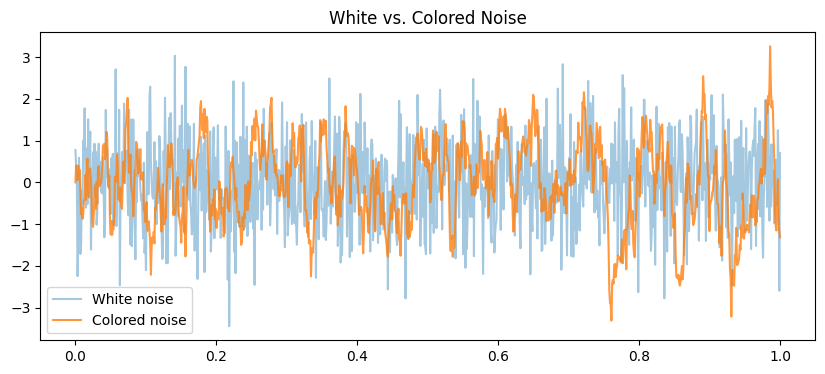

In [141]:
n = 1000
T = 1
dt = T/n
t = np.linspace(0, T, n)

# White noise
white = np.random.normal(0, 1, n)

# Colored noise (simple first-order correlation)
alpha = 0.9
colored = np.zeros(n)
for i in range(1, n):
    colored[i] = alpha*colored[i-1] + np.sqrt(1-alpha**2)*np.random.normal()

plt.figure(figsize=(10,4))
plt.plot(t, white, label='White noise', alpha=0.4)
plt.plot(t, colored, label='Colored noise', alpha=0.8)
plt.legend()
plt.title("White vs. Colored Noise")
plt.show()